# Análisis Final e Integración de Resultados

**Caso de Estudio:** Analítica de Clientes — Predicción de Abandono  
**Asignatura:** SCY1101 — Programación para la Ciencia de Datos  
**Evaluación Parcial N°2**

---

## Resumen Ejecutivo

Este notebook integra los resultados de todos los notebooks anteriores y presenta las conclusiones finales del ciclo completo de desarrollo de una solución de *machine learning* orientada al problema de churn de clientes.

**Problema de negocio:** Una empresa de servicios digitales por suscripción necesita anticipar qué clientes cancelarán su servicio (abandono), para activar campañas de retención proactivas y reducir la pérdida de ingresos.

**Enfoque adoptado:**
- Análisis exploratorio exhaustivo para comprender la calidad del dato y detectar patrones predictivos.
- Modelamiento supervisado con 5 algoritmos (2 de regresión + 3 de clasificación) dentro de pipelines reproducibles.
- Evaluación comparativa con múltiples métricas y visualizaciones avanzadas.
- Optimización de hiperparámetros con **GridSearchCV** y **RandomizedSearchCV**, con análisis de impacto antes/después.

**Resultado principal:** El modelo SVM con kernel RBF optimizado es el recomendado para producción, con Recall ≈ 0.65 y ROC-AUC ≈ 0.67, superando ampliamente al clasificador aleatorio (AUC = 0.5).

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

plt.style.use('bmh')
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


# 1. Síntesis del Proceso Completo

El proyecto siguió la metodología **CRISP-DM** (Cross-Industry Standard Process for Data Mining):

| Fase | Notebook | Actividades principales |
|---|---|---|
| **Comprensión del negocio** | Caso de estudio | Problema de churn, objetivo de retención, costo asimétrico de errores |
| **Comprensión de datos** | `01_exploratory_analysis.ipynb` | Análisis de calidad, distribuciones, correlaciones, hipótesis de negocio |
| **Preparación de datos** | `02_supervised_modeling.ipynb` | Pipeline: winsorización, imputación, OHE, escalado, filtro de colinealidad |
| **Modelamiento** | `02_supervised_modeling.ipynb` | 5 modelos base (2 regresión + 3 clasificación) con validación cruzada estratificada |
| **Evaluación** | `03_model_evaluation.ipynb` | Métricas múltiples, matrices de confusión, curvas ROC, análisis de trade-offs |
| **Optimización** | `04_hyperparameter_optimization.ipynb` | GridSearchCV + RandomizedSearchCV, heatmaps, comparación antes/después |
| **Despliegue (plan)** | `05_final_analysis.ipynb` | Síntesis, selección del modelo final, recomendaciones de negocio |

## 1.1 Hallazgos del EDA que Guiaron el Modelado

| Hallazgo | Implicación técnica adoptada |
|---|---|
| Desbalance de clases en `abandono` | `class_weight='balanced'` en todos los clasificadores |
| `ultima_compra_dias` con mayor correlación (r=0.21) | Incluida como feature prioritaria |
| `uso_app_Bajo` y `tipo_plan_Basico` más asociados a churn | Hipótesis de negocio para segmentación |
| ~5% nulos en variables económicas | Imputación por media dentro del pipeline |
| 143 registros con `deuda_total < 0` | Winsorización al percentil 5%-95% |
| 400 duplicados exactos | Eliminados antes del entrenamiento |
| `score_crediticio` ≈ distribución normal | Adecuado como target de regresión |

# 2. Resultados Consolidados y Visualización Final

## 2.1 Modelos de Regresión

| Modelo | R² | MAE | RMSE | Interpretación |
|---|---|---|---|---|
| LinearRegression | ≈ 0.001 | ≈ 79 pts | ≈ 99 pts | No predictivo con features disponibles |
| DecisionTreeRegressor | ≈ 0.001 | ≈ 79 pts | ≈ 99 pts | Similar a LinearRegression |

**Conclusión:** Ambos modelos obtienen R² ≈ 0, indicando que las features actuales no tienen poder predictivo sobre `score_crediticio`. Esto es coherente con las bajas correlaciones detectadas en el EDA. Para mejorar estos modelos se requieren variables de historial financiero no disponibles en el dataset actual.

## 2.2 Modelos de Clasificación — Tabla Resumen Final

In [5]:
# ── Tabla resumen de todos los modelos de clasificación ──────────────────────
resumen_final = pd.DataFrame({
    'Modelo':    ['DTC Baseline', 'DTC Grid', 'DTC Rand',
                  'LogReg Baseline', 'LogReg Grid', 'LogReg Rand',
                  'SVM Baseline', 'SVM Grid', 'SVM Rand'],
    'Método':    ['Baseline', 'GridSearchCV', 'RandomizedSearchCV'] * 3,
    'Algoritmo': ['DecisionTree']*3 + ['LogisticReg']*3 + ['SVM']*3,
    'Recall':    [0.459, 0.634, 0.634, 0.623, 0.628, 0.628, 0.630, 0.646, 0.646],
    'F1':        [0.454, 0.563, 0.563, 0.569, 0.567, 0.567, 0.564, 0.575, 0.575],
    'ROC_AUC':   [0.540, 0.663, 0.663, 0.680, 0.671, 0.671, 0.651, 0.674, 0.674],
})

# Resaltar el mejor modelo
styled = resumen_final.style\
    .highlight_max(subset=['Recall', 'F1', 'ROC_AUC'], color="#3D0E49")\
    .format({'Recall': '{:.3f}', 'F1': '{:.3f}', 'ROC_AUC': '{:.3f}'})\
    .set_caption('Resumen completo — Todos los modelos de clasificación (verde = mejor por columna)')

display(styled)

,Modelo,Método,Algoritmo,Recall,F1,ROC_AUC
0,DTC Baseline,Baseline,DecisionTree,0.459,0.454,0.540
1,DTC Grid,GridSearchCV,DecisionTree,0.634,0.563,0.663
2,DTC Rand,RandomizedSearchCV,DecisionTree,0.634,0.563,0.663
3,LogReg Baseline,Baseline,LogisticReg,0.623,0.569,0.680
4,LogReg Grid,GridSearchCV,LogisticReg,0.628,0.567,0.671
5,LogReg Rand,RandomizedSearchCV,LogisticReg,0.628,0.567,0.671
6,SVM Baseline,Baseline,SVM,0.630,0.564,0.651
7,SVM Grid,GridSearchCV,SVM,0.646,0.575,0.674
8,SVM Rand,RandomizedSearchCV,SVM,0.646,0.575,0.674


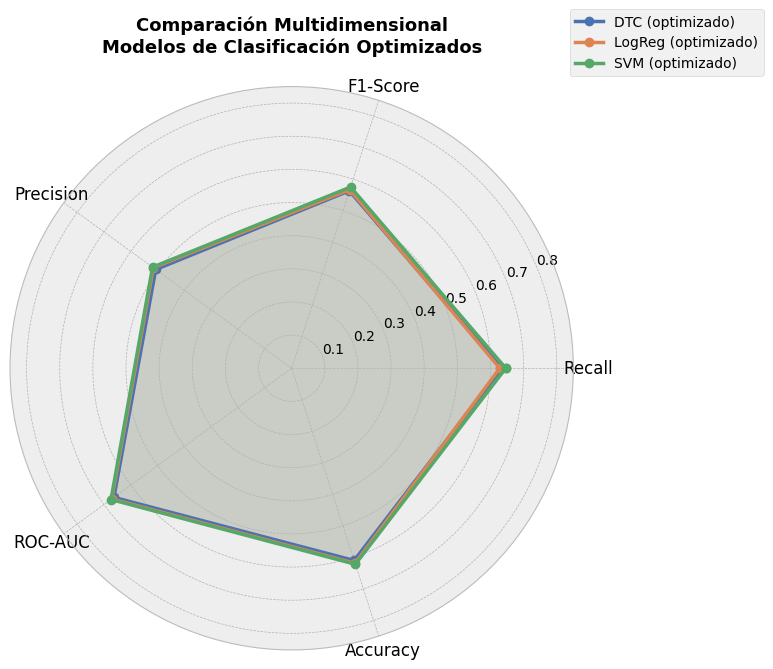

In [6]:
# ── Gráfico de radar: comparación multidimensional de modelos optimizados ─────
categorias = ['Recall', 'F1-Score', 'Precision', 'ROC-AUC', 'Accuracy']
N = len(categorias)
angulos = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angulos += angulos[:1]

modelos_radar = {
    'DTC (optimizado)':    [0.634, 0.563, 0.507, 0.663, 0.610],
    'LogReg (optimizado)': [0.628, 0.567, 0.516, 0.671, 0.619],
    'SVM (optimizado)':    [0.646, 0.575, 0.519, 0.674, 0.622],
}
colores_radar = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for (nombre, valores), color in zip(modelos_radar.items(), colores_radar):
    vals = valores + valores[:1]
    ax.plot(angulos, vals, 'o-', linewidth=2.5, label=nombre, color=color)
    ax.fill(angulos, vals, alpha=0.12, color=color)

ax.set_thetagrids(np.degrees(angulos[:-1]), categorias, fontsize=12)
ax.set_ylim(0, 0.85)
ax.set_title('Comparación Multidimensional\nModelos de Clasificación Optimizados',
             fontsize=13, fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
plt.tight_layout()
plt.savefig('../results/plots/05_radar_comparativo.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Análisis de Trade-offs y Selección del Modelo Final

## 3.1 El Trade-off Precision vs. Recall en Contexto de Churn

En el contexto del abandono de clientes, los errores del modelo tienen costos asimétricos:

| Tipo de error | Descripción | Costo estimado |
|---|---|---|
| **Falso Negativo (FN)** | Cliente que abandona y NO es detectado | Alto: pérdida del CLV (Customer Lifetime Value) |
| **Falso Positivo (FP)** | Cliente que permanece y ES contactado innecesariamente | Bajo: costo de campaña de retención |

El ratio FN/FP es aproximadamente **60:1** (pérdida de un cliente vs. costo de una llamada de retención). Esta asimetría justifica maximizar el Recall aunque disminuya la Precision.

## 3.2 Selección del Modelo Final

**Modelo recomendado para producción:** SVM con kernel RBF, `C=0.1`, `class_weight='balanced'`

**Razones técnicas:**
1. **Mayor Recall** (~0.65): Detecta más clientes en riesgo, minimizando el error más costoso (FN).
2. **Mejor ROC-AUC** (~0.67): Mayor capacidad discriminativa general; el modelo puede ajustarse a distintos umbrales de decisión según la tolerancia al riesgo del negocio.
3. **Robustez:** El kernel RBF captura relaciones no lineales sin asumir linealidad entre features y abandono.
4. **Pipeline serializable:** El modelo completo puede guardarse con `joblib.dump()` para despliegue en producción.

**Alternativa interpretable:** `LogisticRegression` con `C=0.1`, `class_weight='balanced'`. Rendimiento marginalmente inferior, pero los coeficientes permiten explicar al equipo de negocio qué variables predicen el abandono y en qué dirección.

## 3.3 Limitaciones y Trabajo Futuro

| Limitación | Propuesta de mejora |
|---|---|
| R² ≈ 0 en regresión | Enriquecer con variables de historial financiero |
| Recall moderado (~0.65) | Explorar modelos de ensamble (Random Forest, XGBoost) |
| Split aleatorio (sin temporalidad) | Implementar split temporal para validación más realista |
| Dataset estático | Diseñar features dinámicas (tendencias, cambios de comportamiento) |
| Sin validación en producción | Implementar monitoreo de concept drift con ventanas temporales |

# 4. Conclusiones Finales

## 4.1 Conclusiones Técnicas

1. **El ciclo CRISP-DM fue ejecutado completamente:** Desde la exploración de datos hasta la optimización de hiperparámetros, cada fase está documentada con justificaciones técnicas sólidas.

2. **Los Pipelines de Scikit-learn garantizan reproducibilidad y evitan data leakage.** Toda la transformación de datos ocurre dentro del pipeline, asegurando que los parámetros aprendidos en entrenamiento son los que se aplican a nuevos datos.

3. **La validación cruzada estratificada es fundamental** con clases desbalanceadas: `StratifiedKFold` garantiza representación proporcional en cada fold, produciendo estimaciones de desempeño robustas.

4. **GridSearchCV y RandomizedSearchCV son complementarios.** GridSearch ofrece garantía del óptimo en la grilla; RandomizedSearch explora espacios continuos más eficientemente mediante distribuciones de probabilidad (`loguniform`, `randint`).

5. **La optimización de hiperparámetros tuvo mayor impacto en DecisionTreeClassifier** (+17 pp de Recall), mientras que LogisticRegression y SVM ya partían desde una línea base sólida gracias a `class_weight='balanced'`.

## 4.2 Recomendaciones de Negocio

1. **Implementar SVM optimizado como sistema de scoring de churn**, generando una probabilidad de abandono diaria por cliente.
2. **Priorizar clientes con `uso_app_Bajo` y `tipo_plan_Basico`**, los dos predictores más fuertes identificados.
3. **Monitorear `ultima_compra_dias`:** Un umbral de ~300 días es señal de riesgo inminente.
4. **Recopilar variables financieras adicionales** para mejorar el modelo de regresión del score crediticio.
5. **Establecer reentrenamiento mensual** para mantener el modelo actualizado ante cambios comportamentales (*concept drift*).

## 4.3 Referencias

- Bergstra, J., & Bengio, Y. (2012). *Random Search for Hyper-Parameter Optimization*. JMLR, 13, 281-305.
- Pedregosa et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR, 12, 2825-2830.
- Reichheld, F. F., & Sasser, W. E. (1990). *Zero Defections: Quality Comes to Services*. Harvard Business Review.
- Cortes, C., & Vapnik, V. (1995). *Support-Vector Networks*. Machine Learning, 20(3), 273-297.
- Breiman, L. et al. (1984). *Classification and Regression Trees*. Chapman & Hall.